In [1]:
from imports import *
from scipy.stats import iqr
from local_tools.math import cohstats
from scipy.ndimage import gaussian_filter
cat = catalog.copy()
octavg=lt.math.octave_average
# Figure priorities:
# 1. Transfer Functions for a deep and shallow station
# 2. Map
# 3. Single station ZZ coherence for a deep and shallow
# 4. 8x spectrograms deep/shallow x atacr/hps x pre/post

In [2]:
# k=keys[0]
# days=get_day_tfs(stanm)
# upper,lower,median,outliers,inliers = cohstats(np.array([abs(d.transfunc['ZP-21'][k]) for d in days]))

In [3]:
# -----TF-data
get_tf = lambda stanm:load_pickle(list((dirs.TransferFunctions/stanm).glob('*-*.pkl'))[0])
get_day_tfs = lambda stanm: [load_pickle(i) for i in [f for f in list((dirs.TransferFunctions/stanm).glob('*.pkl')) if str(f).find('-')<0]]
# -----ZZ Event Coherence data
report=get_reports('ZZ',catalog,dirs.Archive,dirs,AVG=True)

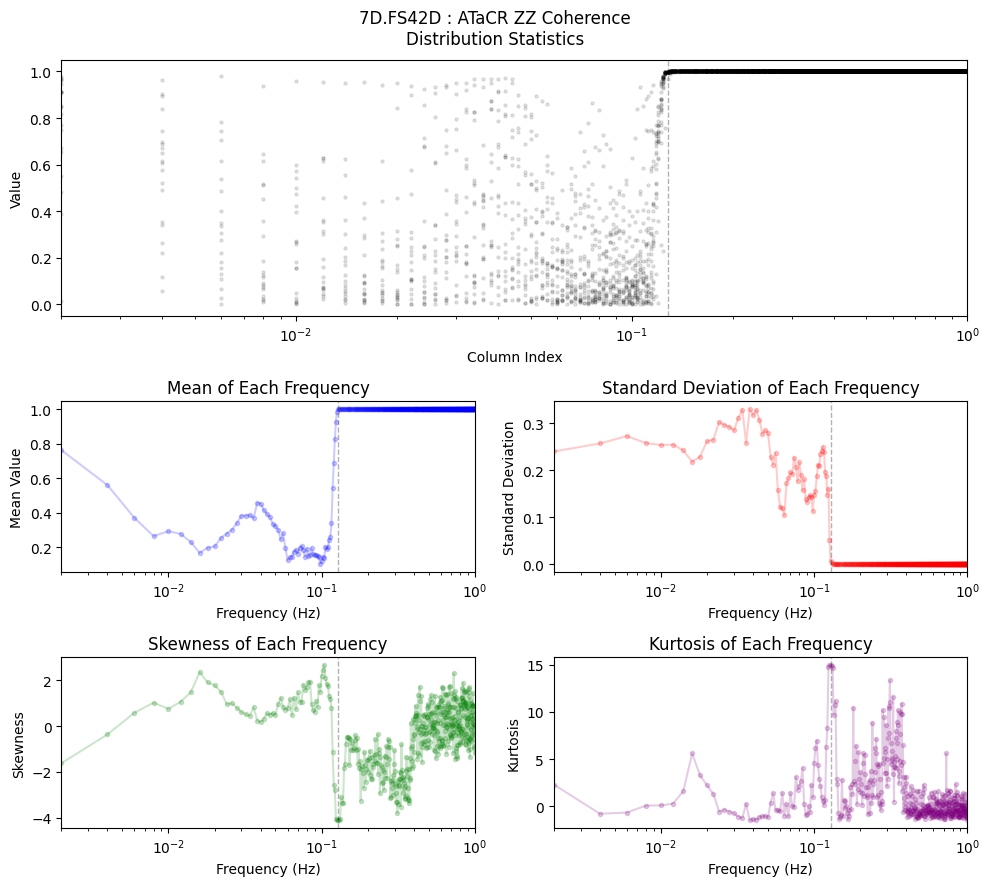

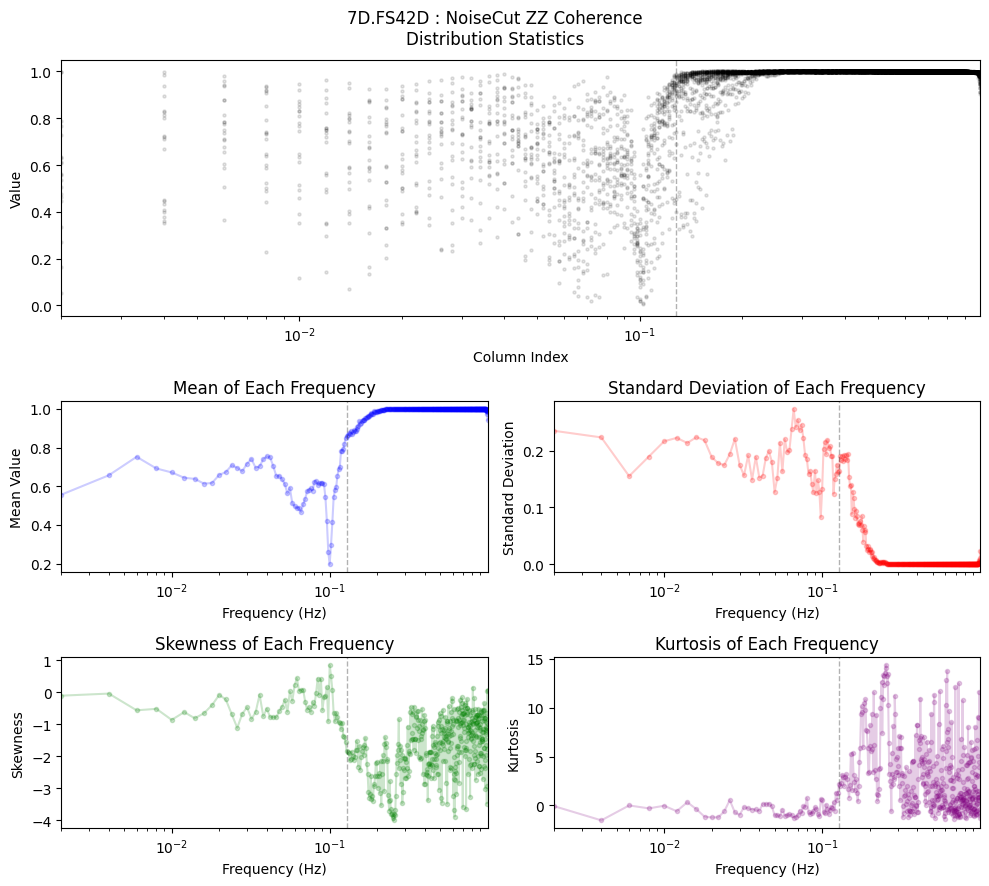

In [4]:
sta=cat.loc['7D.FS42D'];stanm=sta.StaName
method='ATaCR'
f = report.f;ind=f<=1;f=f[ind]
coh=report[method][stanm].coh[:,ind]
lt.plots.analyze_distribution(f[f<=1],fnotch(sta.StaDepth),coh,f'{stanm} : {method} ZZ Coherence\nDistribution Statistics')
method='NoiseCut'
f = report.f;ind=(f>0)&(f<1);f=f[ind]
coh=report[method][stanm].coh[:,ind]
lt.plots.analyze_distribution(f[f<=1],fnotch(sta.StaDepth),coh,f'{stanm} : {method} ZZ Coherence\nDistribution Statistics')

In [5]:
minmag=7.4
cat=catalog.copy()
cat = pd.concat([cat.sort_values(by='StaDepth')[:15].copy(),cat.sort_values(by='StaDepth')[-15:].copy()])
flim = [1/230,1]
# ----------------------------------------------------------------------------------------
outlierprops={'color':'r','s':10,'alpha':0.09}
inlierprops={'color':'dodgerblue','s':13,'alpha':0.2} #'#7370cb' royalblue dodgerblue
whiskerprops={'linewidth':0.5,'color':'k'}
whiskerwidth=0.002;margin=1.02
midlineprops={'linewidth':1.5,'color':'k','alpha':0.8}
loglogprops={'linewidth':1.5,'color':'k','alpha':0.8,'nonpositive':'mask'}
midscatterprops={'s':10,'color':'k'} #args.csd_pairs[pair]
notchprops = {'alpha':0.4,'linewidth':2,'color':'k','linestyle':'-.'}
# labelprops = {'fontweight':'bold','fontsize':12}
labelprops = {'fontsize':12}
methodlabelprops = {'fontweight':'bold','fontsize':15,'verticalalignment':'bottom','horizontalalignment':'right'}
# ----------------------------------------------------------------------------------------


In [ ]:
# octave_av

In [ ]:
# fig,ax=plt.subplots(1,1,figsize=(10,3))
# # ax=ax[0]
# # ax=axes[0]
# tfs=get_tf(stanm)
# f=tfs.f
# ind=(f>0)&(f<=1);f=f[ind]
# [ax.scatter(f,abs(tfs.transfunc['ZP-21'][k][ind]),s=1,label=k.replace('TF_','')) for k in keys]
# ax.set_yscale('log')
# ax.set_xscale('log')
# ax.legend(markerscale=10,ncols=2,loc='upper right',columnspacing=0,prop={'weight': 'bold'})
# ax.axvline(fnotch(sta.StaDepth),**notchprops)
# ax.set_ylabel('Frequency, Hz',**labelprops)
# ax.set_title(f'"Figure: {stanm}"',fontstyle='italic')
# # ----------
# ax.set_xlim(flim[0],flim[1])
# ax.set_ylim(0,10**np.ceil(max(np.log10(ax.get_xlim()))))


In [6]:
fold=dirs.Ch1/'SingleStationZZCoherences'
fold.mkdir(exist_ok=True)
for si,sta in enumerate(cat.sort_values(by='StaDepth')[:15].iloc):
    fname = f'{int(sta.StaDepth)}m.Shallow.ZZ.Coherence.{sta.StaName}.png'
    fig=sta_metrics(report,sta)
    save_tight(fold/fname,fig)
    print(f'{si+1} | {fname}')
    plt.close('all')
for si,sta in enumerate(cat.sort_values(by='StaDepth')[-15:].iloc):
    fname = f'{int(sta.StaDepth)}m.Deep.ZZ.Coherence.{sta.StaName}.png'
    fig=sta_metrics(report,sta)
    save_tight(fold/fname,fig)
    print(f'{si+1} | {fname}')
    plt.close('all')

NameError: name 'sta_metrics' is not defined

In [ ]:
fold=dirs.Ch1/'SingleStationZZCoherences'
fold.mkdir(exist_ok=True)
for si,sta in enumerate(cat.sort_values(by='StaDepth').iloc):
    fname = f'{int(sta.StaDepth)}m.ZZ.Coherence.{sta.StaName}.png'
    fig=sta_metrics(report,sta)
    save_tight(fold/'EveryStation'/fname,fig)
    print(f'{si+1} | {fname}')
    plt.close('all')